In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from pathlib import Path
import sys, os
sys.path.append(str(Path(os.getcwd()).parent))
from tqdm import tqdm

from src.model.e2c import ConvVAE
from src.model.loss import VAELoss
from src.dataset import E2CDataset
from IPython.display import display, clear_output
from collections import defaultdict
import random

import torch.nn.functional as F

In [2]:
# Load Dataset
# yaml file to pass, which just has dataset name, etc
config_file = Path(os.getcwd()) / "../config/bobcat_11.yaml"
with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
dataset = E2CDataset(config)
batch_size = 128
# split dataset into train and val
# take half the dataset for now, for faster training
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

/home/ayush/Desktop/sawyer_moveit_ws/src/E2C/src/dataset.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(dataset_dir / dataset_file)


In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
enc_latent_size = 64
stochastic_size = 32
vae = {}
vae.update(
    { 'in_image_shape': (9, 64, 64),
      'out_image_shape': (3, 64, 64),
      'enc_latent_size': 64,
      'enc_kernel_size': 3,
      'dec_kernel_size': 3,
      'stride': 2,
      'pad': 1,
    }
)
loss_params = {
    'recon_mult': 5e3,
    'beta': 8e-4,
    'lambda': 2e-5,
    'kld_anneal_mode': 'linear'
}
num_epochs = 100

num_batchs = 50
buffer_capacity = 4000
learning_rate = 3e-4

# TODO:
- decrease fcc layers! control freq has plummeted...
- check uncertainty output as RGB --> can this be used as spatial pdf for ergodic search?

In [4]:
model = ConvVAE(
    enc_latent_size=enc_latent_size,
    stochastic_size=stochastic_size, 
    conv_params=vae, 
    device=device, 
    output_uncertainty=True
    ).to(device)
loss_fn = VAELoss(num_epochs=num_epochs, loss_params=loss_params)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=config['trans']['weight_decay'])

plot_history = {}

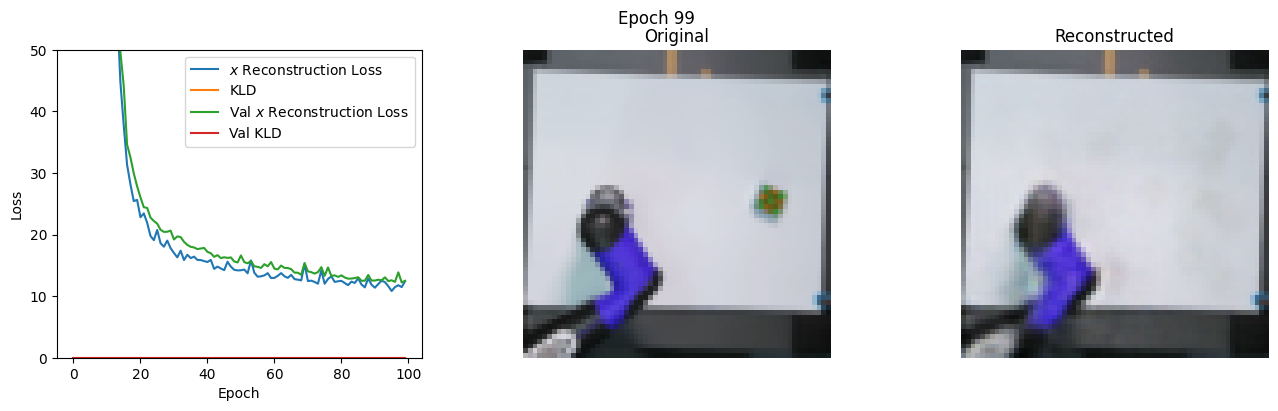

Training Epochs: 100%|██████████| 100/100 [08:29<00:00,  5.14s/it, Epoch=100, Model Loss=0.0923]


In [5]:
plot_history = defaultdict(list)
plot_epochs = []

def plot_reconstruction(fig, ax, original, reconstructed, loss_terms, val_loss_dict, epoch):
    if not plot_epochs or plot_epochs[-1] != epoch:
        plot_epochs.append(epoch)

    for key, val in loss_terms.items():
        plot_history[key].append(val)
    for key, val in val_loss_dict.items():
        plot_history[key].append(val)

    ax[0].clear()
    for key, vals in plot_history.items():
        ax[0].plot(plot_epochs, vals, label=key)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_ylim([0, 50])
    ax[0].legend()

    ax[1].clear()
    ax[1].imshow(np.transpose(original[0].detach().cpu().numpy(), (1, 2, 0)))
    ax[1].set_title("Original")
    ax[1].axis("off")

    ax[2].clear()
    ax[2].imshow(np.transpose(reconstructed[0].detach().cpu().numpy(), (1, 2, 0)))
    ax[2].set_title("Reconstructed")
    ax[2].axis("off")

    fig.suptitle(f"Epoch {epoch}")
    plt.pause(0.01)

# Create figure once before the loop
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

pbar = tqdm(total=num_epochs, desc="Training Epochs")
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    # for batch_idx, data in enumerate(train_loader):
    for batch_idx in range(num_batchs):
        x, x_next, u = dataset[random.sample(range(buffer_capacity + (epoch+1)*num_batchs), min(batch_size, (epoch+1)*num_batchs))]
        # x = x.reshape(x.shape[0], -1, *vae['in_image_shape'][1:])
        inputs = x[:, -1].to(device)
        optimizer.zero_grad()
        tr = model(inputs)
        enc_real = model.encoder.encoder_cnn(tr['x'].detach())
        enc_fake = model.encoder.encoder_cnn(tr['x_recon'].detach())
        loss, loss_terms = loss_fn(tr, epoch)
        feat_loss = 0.5 * F.mse_loss(enc_real, enc_fake)
        loss += feat_loss
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        if batch_idx == 0:
            print(f"Loss: {loss.item()}, Feature Loss: {feat_loss.item()}, Ratio: {feat_loss.item() / loss.item()}")
        
            # print(f"Train Epoch: {epoch} [{batch_idx * len(inputs)}/{len(train_loader.dataset)} "
            #       f"({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item() / len(inputs):.6f}")
    model.eval()
    val_loss_dict = {}
    for (x_val, x_next_val, u_val) in val_loader:
        x_val, x_next_val, u_val = x_val.to(device), x_next_val.to(device).to(torch.float32), u_val.to(device).to(torch.float32)
        x_val = x_val.reshape(x_val.shape[0], -1, *(3, 64, 64)).to(torch.float32)    # Stack obs history in channel dim

        # Forward pass
        with torch.cuda.amp.autocast():
            inputs = x_val[:, -1].to(device)
            val_return = model(inputs)
            val_loss, val_loss_return = loss_fn(val_return, epoch)
    
    for keys, vals in val_loss_return.items():
        print(f"{keys}: {vals}")
        val_loss_dict[f"Val {keys}"] = vals
    model.train()
    
    # plot_reconstruction(fig, ax, tr['x'], tr['x_recon'], loss_terms, epoch)
    plot_reconstruction(fig, ax, tr['x'], tr['x_recon'], loss_terms, val_loss_dict, epoch)
    # --- update display ---
    clear_output(wait=True)
    display(fig)
    plt.pause(0.01)
    pbar.set_postfix({
        'Epoch': epoch+1,
        'Model Loss': f"{train_loss / (num_batchs * batch_size):.4f}"})
    pbar.update(1)

plt.show()
pbar.close()

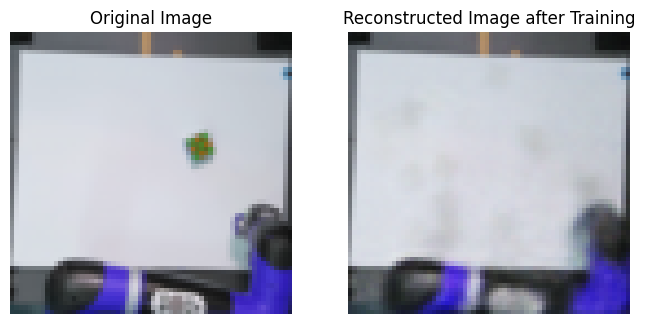

In [6]:
model.eval()
x, x_next, u = dataset[random.sample(range(train_size), batch_size)]
# x = x.reshape(x.shape[0], -1, *vae['in_image_shape'][1:])
inputs = x[:, -1].to(device)
optimizer.zero_grad()
tr = model(inputs)
fig2, ax2 = plt.subplots(1, 2, figsize=(8, 4))
ax2[0].imshow(np.transpose(tr['x'][0].detach().cpu().numpy(), (1, 2, 0)))
ax2[0].set_title("Original Image")
ax2[0].axis("off")
ax2[1].imshow(np.transpose(tr['x_recon'][0].detach().cpu().numpy(), (1, 2, 0)))
ax2[1].set_title("Reconstructed Image after Training")
ax2[1].axis("off")
plt.show()